# Illustration — injection des consignes de setpoint (non stochastiques) dans le time series

**Bâtiment 57826** (Iowa) — tiré des 153 bâtiments filtrés (maison individuelle plain-pied,
chauffage électrique, sans VE/piscine/PV, occupée).

## Problème
Dans la release ResStock 2025, les colonnes `out.schedules.cooling_setpoint..c` et
`out.schedules.heating_setpoint..c` du time series sont **entièrement vides** : les consignes
sont des schedules *non stochastiques*, appliqués dans EnergyPlus mais non ré-exportés.

## Idée
La consigne horaire est **entièrement déterministe** : on la **reconstruit** à partir de
4 caractéristiques statiques (métadonnées) + le masque horaire réel de `options_lookup.tsv`,
puis on l'**injecte** dans le time series et on visualise sa relation avec la température
intérieure réelle (`out.indoor_temperature.conditioned_space..c`).

> On commence par la **climatisation**, puis on montre le rôle **saisonnier** des deux consignes.

## 0. Configuration & imports

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ROOT     = Path.cwd().parents[1] if Path.cwd().name == '06_timeseries' else Path.cwd()
DATA     = ROOT / 'data' / 'processed'
LOOKUP   = ROOT / 'data' / 'external' / 'options_lookup.tsv'

BLDG_ID  = 57826
TS_FILE  = DATA / f'{BLDG_ID}-0_full.parquet'          # time series complet (192 colonnes)
META     = DATA / 'metadata_clean.parquet'
T_COL    = 'out.indoor_temperature.conditioned_space..c'
COOL_COL = 'out.electricity.cooling.energy_consumption..kwh'

plt.rcParams['figure.dpi'] = 110

## 1. Caractéristiques de consigne du bâtiment (statique)

Chaque consigne est décrite par 4 attributs : la **base**, la présence d'un **offset**,
sa **magnitude** (un écart, en °F) et sa **période** (quelles heures, quel sens).

In [2]:
meta  = pd.read_parquet(META)
carac = meta.loc[meta['bldg_id'] == BLDG_ID].iloc[0]

attrs = ['in.state', 'in.hvac_cooling_type', 'in.hvac_heating_type_and_fuel',
         'in.cooling_setpoint', 'in.cooling_setpoint_has_offset',
         'in.cooling_setpoint_offset_magnitude', 'in.cooling_setpoint_offset_period',
         'in.heating_setpoint', 'in.heating_setpoint_has_offset',
         'in.heating_setpoint_offset_magnitude', 'in.heating_setpoint_offset_period']
pd.DataFrame({'valeur': carac[attrs]})

,valeur
in.state,IA
in.hvac_cooling_type,Room AC
in.hvac_heating_type_and_fuel,Electricity Electric Boiler
in.cooling_setpoint,76F
in.cooling_setpoint_has_offset,Yes
in.cooling_setpoint_offset_magnitude,9F
in.cooling_setpoint_offset_period,Day Setup and Night Setback
in.heating_setpoint,68F
in.heating_setpoint_has_offset,Yes
in.heating_setpoint_offset_magnitude,6F


## 2. Reconstruction des consignes horaires

**Conversions °F → °C** — attention à la nature de la grandeur :
- une **consigne** est une température *absolue* → `(F − 32) × 5/9`
- une **magnitude d'offset** est un *écart* → `F × 5/9` (surtout **pas** le −32)

**Masque horaire** (`options_lookup.tsv`) — vecteur de 24 valeurs **signées** :
`+1` = *setup* (consigne relevée), `−1` = *setback* (consigne abaissée), `0` = base.
Le masque diffère entre **semaine** et **week-end**. La consigne finale est simplement :

$$\text{consigne}(h) = \text{base} + \text{masque}(h)\times\text{magnitude}$$

In [3]:
# '76F' -> 24.44  (température absolue)
def f_abs_to_c(txt):
    return round((float(re.search(r'[-\d.]+', str(txt)).group()) - 32) * 5 / 9, 2)

# '9F' -> 5.0  (écart de température : pas de -32)
def f_delta_to_c(txt):
    return round(float(re.search(r'[-\d.]+', str(txt)).group()) * 5 / 9, 2)

# lecture des masques horaires depuis options_lookup.tsv
# (nombre de colonnes variable selon les lignes -> lecture texte brute)
LOOKUP_LINES = LOOKUP.read_text(encoding='utf-8').splitlines()

# renvoie (masque_semaine[24], masque_weekend[24]) pour une période donnée
def get_masks(characteristic, period):
    if pd.isna(period) or str(period).strip().lower() == 'none':
        return np.zeros(24), np.zeros(24)
    prefix = f'{characteristic}\t{period}\t'
    line = next((l for l in LOOKUP_LINES if l.startswith(prefix)), None)
    if line is None:
        raise ValueError(f'{characteristic} / {period} introuvable dans options_lookup')
    wk = re.search(r'weekday_setpoint_schedule=([-\d,\s]+)', line).group(1)
    we = re.search(r'weekend_setpoint_schedule=([-\d,\s]+)', line).group(1)
    to_arr = lambda s: np.array([int(x) for x in s.split(',')][:24], dtype=float)
    return to_arr(wk), to_arr(we)

# série horaire de consigne injectée sur l'index temporel du time series
def reconstruire(ts_index, base_c, mag_c, wk_mask, we_mask):
    h  = ts_index.hour.values
    we = ts_index.dayofweek.values >= 5           # samedi/dimanche
    m  = np.where(we, we_mask[h], wk_mask[h])
    return base_c + m * mag_c

In [4]:
# Consigne CLIM
cool_base = f_abs_to_c(carac['in.cooling_setpoint'])
cool_mag  = f_delta_to_c(carac['in.cooling_setpoint_offset_magnitude'])
cool_per  = carac['in.cooling_setpoint_offset_period']
cool_wk, cool_we = get_masks('Cooling Setpoint Offset Period', cool_per)

# Consigne CHAUFFAGE
heat_base = f_abs_to_c(carac['in.heating_setpoint'])
heat_mag  = f_delta_to_c(carac['in.heating_setpoint_offset_magnitude'])
heat_per  = carac['in.heating_setpoint_offset_period']
heat_wk, heat_we = get_masks('Heating Setpoint Offset Period', heat_per)

print(f'CLIM      base={cool_base}C  mag={cool_mag}C  periode={cool_per}')
print('  masque semaine :', cool_wk.astype(int))
print('  profil semaine :', np.round(cool_base + cool_wk * cool_mag, 1))
print(f'CHAUFFAGE base={heat_base}C  mag={heat_mag}C  periode={heat_per}')
print('  masque semaine :', heat_wk.astype(int))
print('  profil semaine :', np.round(heat_base + heat_wk * heat_mag, 1))

CLIM      base=24.44C  mag=5.0C  periode=Day Setup and Night Setback
  masque semaine : [-1 -1 -1 -1 -1 -1 -1  0  0  1  1  1  1  1  1  1  1  0  0  0  0  0 -1 -1]
  profil semaine : [19.4 19.4 19.4 19.4 19.4 19.4 19.4 24.4 24.4 29.4 29.4 29.4 29.4 29.4
 29.4 29.4 29.4 24.4 24.4 24.4 24.4 24.4 19.4 19.4]
CHAUFFAGE base=20.0C  mag=3.33C  periode=Night +3h
  masque semaine : [ 0 -1 -1 -1 -1 -1 -1 -1 -1 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
  profil semaine : [20.  16.7 16.7 16.7 16.7 16.7 16.7 16.7 16.7 16.7 20.  20.  20.  20.
 20.  20.  20.  20.  20.  20.  20.  20.  20.  20. ]


## 3. Injection dans le time series

In [5]:
ts = pd.read_parquet(TS_FILE).set_index('timestamp').sort_index()

ts['setpoint_cooling..c'] = reconstruire(ts.index, cool_base, cool_mag, cool_wk, cool_we)
ts['setpoint_heating..c'] = reconstruire(ts.index, heat_base, heat_mag, heat_wk, heat_we)

ts[[T_COL, 'setpoint_cooling..c', 'setpoint_heating..c', COOL_COL]].head()

,out.indoor_temperature.conditioned_space..c,setpoint_cooling..c,setpoint_heating..c,out.electricity.cooling.energy_consumption..kwh
timestamp,,,,
2018-01-01 00:15:00,19.721111,19.44,20.00,0.0
2018-01-01 00:30:00,19.722778,19.44,20.00,0.0
2018-01-01 00:45:00,19.722221,19.44,20.00,0.0
2018-01-01 01:00:00,19.722221,19.44,16.67,0.0
2018-01-01 01:15:00,19.722778,19.44,16.67,0.0


## 4. Visualisation 1 — une semaine d'été : consigne clim injectée vs température intérieure

La consigne reconstruite (créneaux) et la température intérieure réelle doivent « se suivre »
quand la clim est active.

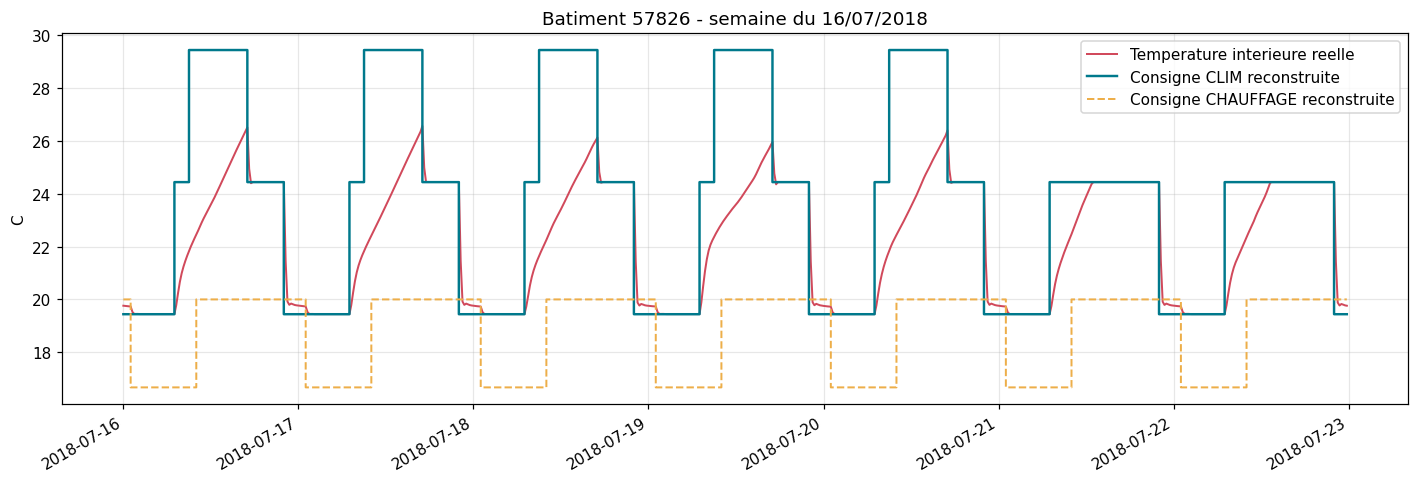

In [6]:
sem = ts.loc['2018-07-16':'2018-07-22']

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(sem.index, sem[T_COL], color='#d1495b', lw=1.3, label='Temperature interieure reelle')
ax.step(sem.index, sem['setpoint_cooling..c'], where='post', color='#00798c', lw=1.6,
        label='Consigne CLIM reconstruite')
ax.step(sem.index, sem['setpoint_heating..c'], where='post', color='#edae49', lw=1.3, ls='--',
        label='Consigne CHAUFFAGE reconstruite')
ax.set_title(f'Batiment {BLDG_ID} - semaine du 16/07/2018')
ax.set_ylabel('C'); ax.legend(loc='upper right'); ax.grid(alpha=.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

**Ce qu'on peut déduire de cette semaine :**

- **La consigne clim est une borne, pas une cible.** La température intérieure est plaquée sur le plancher nocturne (19.4 °C) tant que la clim tient, puis s'en détache et **dérive librement** le jour quand la consigne monte à 29.4 °C (clim à l'arrêt). La Tint n'égale la consigne que sous contrôle actif.
- **La réponse est asymétrique → inertie thermique.** La descente est quasi verticale (la clim refroidit vite), la remontée est **lente et progressive** (dérive gouvernée par l'inertie du bâtiment et la météo). Cette asymétrie révèle la constante de temps du logement.
- **L'effet semaine / week-end se lit à l'œil.** Les 21–22/07, la consigne reste à 24.4 °C en journée (pas de *setup* diurne) au lieu de 29.4 °C en semaine : la distinction du masque `options_lookup` est bien présente dans les données. *(Et le chauffage, en pointillé, n'est jamais atteint — une seule consigne « mord » à la fois.)*

## 5. Visualisation 2 — rôle **saisonnier** des deux consignes (bande morte)

Les consignes ResStock sont **constantes sur l'année** (seule variation : jour/nuit).
Mais un thermostat à double consigne fait **flotter** la température intérieure entre la
consigne chaud (plancher) et la consigne froid (plafond). **Laquelle « mord » est saisonnier** :
- hiver → le chauffage tient le plancher,
- été → la clim tient le plafond.

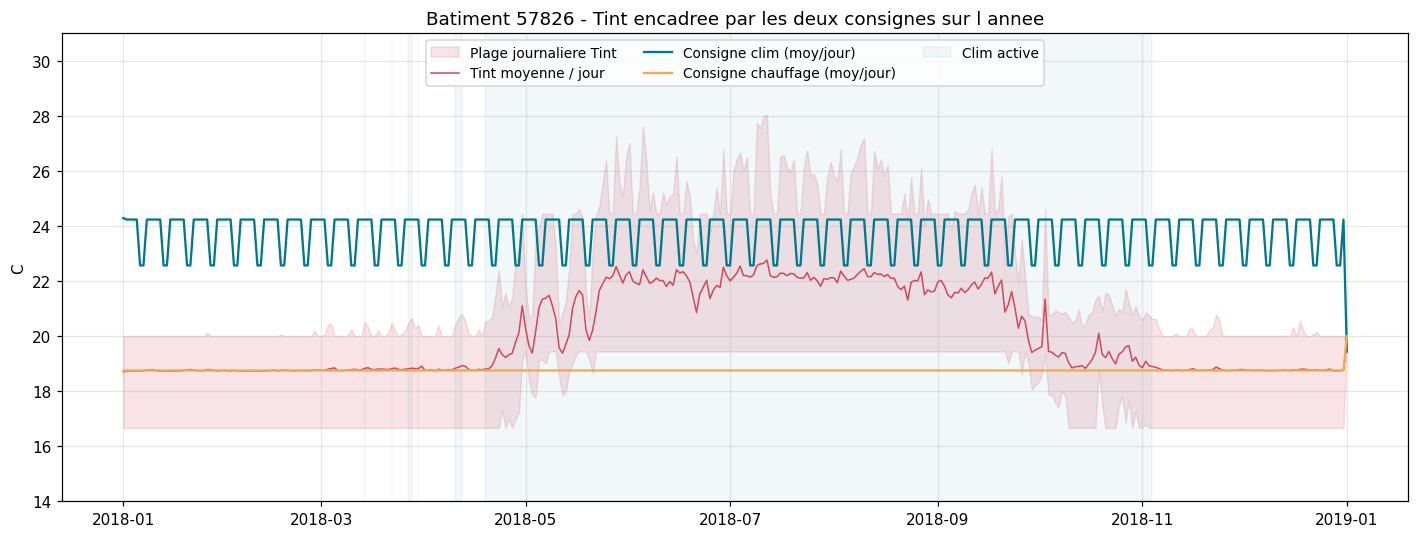

In [7]:
jour = pd.DataFrame({
    'Tint_min': ts[T_COL].resample('D').min(),
    'Tint_moy': ts[T_COL].resample('D').mean(),
    'Tint_max': ts[T_COL].resample('D').max(),
    'cool_sp':  ts['setpoint_cooling..c'].resample('D').mean(),
    'heat_sp':  ts['setpoint_heating..c'].resample('D').mean(),
    'cool_kwh': ts[COOL_COL].resample('D').sum(),
})

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(jour.index, jour['Tint_min'], jour['Tint_max'], color='#d1495b', alpha=.15,
                label='Plage journaliere Tint')
ax.plot(jour.index, jour['Tint_moy'], color='#d1495b', lw=1, label='Tint moyenne / jour')
ax.plot(jour.index, jour['cool_sp'], color='#00798c', lw=1.5, label='Consigne clim (moy/jour)')
ax.plot(jour.index, jour['heat_sp'], color='#edae49', lw=1.5, label='Consigne chauffage (moy/jour)')
active = jour['cool_kwh'] > 0
ax.fill_between(jour.index, 14, 31, where=active, color='#00798c', alpha=.05, label='Clim active')
ax.set_ylim(14, 31); ax.set_ylabel('C')
ax.set_title(f'Batiment {BLDG_ID} - Tint encadree par les deux consignes sur l annee')
ax.legend(loc='upper center', ncol=3, fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Visualisation 3 — corrélation clim ↔ température intérieure (saison de clim)

Hors saison de clim, la consigne froid ne « mord » pas : on restreint la corrélation
aux mois où la clim est réellement active (mai–septembre).

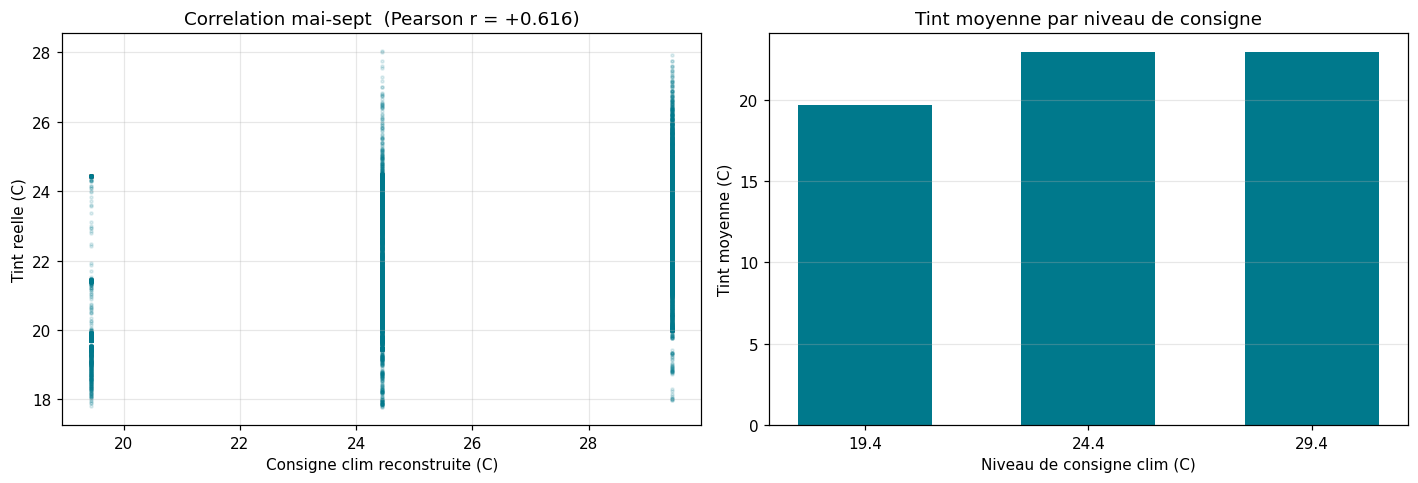

Pearson r (mai-sept) = +0.616   (p = 0.0e+00)
  consigne  19.4 C  ->  Tint moyenne 19.69 C
  consigne  24.4 C  ->  Tint moyenne 22.92 C
  consigne  29.4 C  ->  Tint moyenne 22.94 C


In [8]:
ete = ts[ts.index.month.isin([5, 6, 7, 8, 9])]
sp, tin = ete['setpoint_cooling..c'], ete[T_COL]
r, p = pearsonr(sp, tin)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(sp, tin, s=4, alpha=.12, color='#00798c')
ax[0].set_xlabel('Consigne clim reconstruite (C)'); ax[0].set_ylabel('Tint reelle (C)')
ax[0].set_title(f'Correlation mai-sept  (Pearson r = {r:+.3f})'); ax[0].grid(alpha=.3)

niv = tin.groupby(sp.round(1)).mean()
ax[1].bar(niv.index.astype(str), niv.values, color='#00798c', width=.6)
ax[1].set_xlabel('Niveau de consigne clim (C)'); ax[1].set_ylabel('Tint moyenne (C)')
ax[1].set_title('Tint moyenne par niveau de consigne'); ax[1].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

print(f'Pearson r (mai-sept) = {r:+.3f}   (p = {p:.1e})')
for lvl, v in niv.items():
    print(f'  consigne {lvl:>5} C  ->  Tint moyenne {v:.2f} C')

## 7. Consommation clim ↔ écart moteur

On relie enfin la consigne à la **cible réelle : la consommation**. On définit l'**écart moteur**
`T_extérieure − consigne_clim` (analogue aux *cooling degree-hours*, mais avec la vraie consigne
horaire reconstruite). C'est lui qui **déclenche** et **dose** la climatisation.

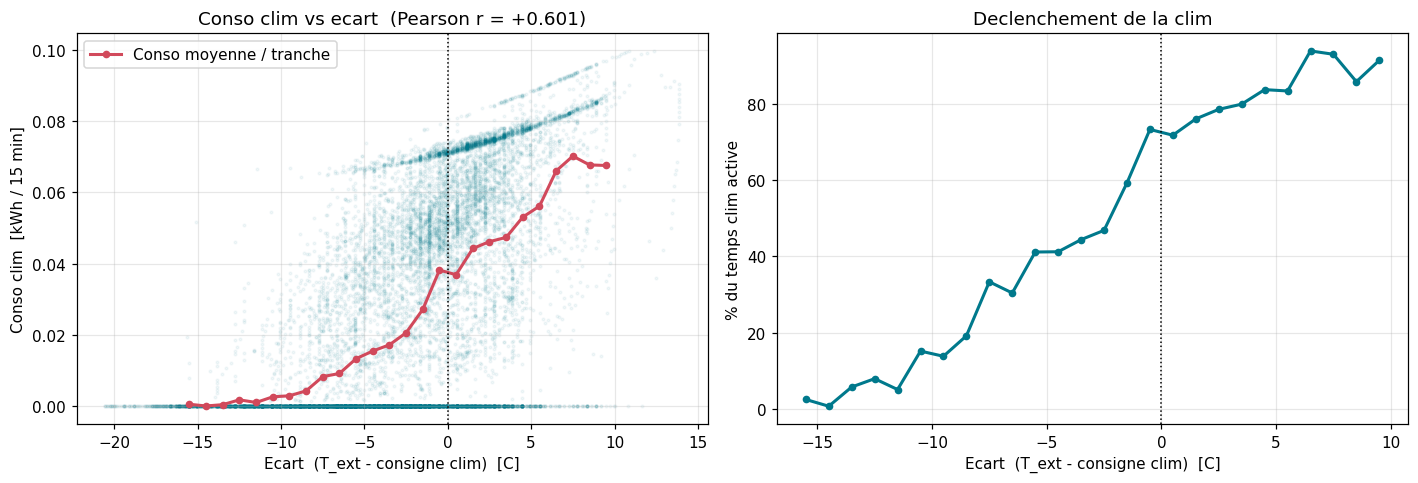

r(ecart, conso clim) mai-sept = +0.601


In [9]:
ete2 = ts[ts.index.month.isin([5, 6, 7, 8, 9])]
gap  = ete2['out.outdoor_air_drybulb_temp..c'] - ete2['setpoint_cooling..c']
conso = ete2[COOL_COL]

# moyenne + % actif par tranche d'écart de 1 °C
bins = np.arange(-16, 14, 1.0)
mid  = (bins[:-1] + bins[1:]) / 2
idx  = np.digitize(gap, bins)
conso_moy = np.array([conso[idx == i].mean()      if (idx == i).sum() > 20 else np.nan for i in range(1, len(bins))])
pct_actif = np.array([(conso[idx == i] > 0).mean() if (idx == i).sum() > 20 else np.nan for i in range(1, len(bins))])

r_gap, _ = pearsonr(gap, conso)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(gap, conso, s=3, alpha=.05, color='#00798c')
ax[0].plot(mid, conso_moy, color='#d1495b', lw=2, marker='o', ms=4, label='Conso moyenne / tranche')
ax[0].axvline(0, color='k', ls=':', lw=1)
ax[0].set_xlabel('Ecart  (T_ext - consigne clim)  [C]'); ax[0].set_ylabel('Conso clim  [kWh / 15 min]')
ax[0].set_title(f'Conso clim vs ecart  (Pearson r = {r_gap:+.3f})'); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(mid, pct_actif * 100, color='#00798c', lw=2, marker='o', ms=4)
ax[1].axvline(0, color='k', ls=':', lw=1)
ax[1].set_xlabel('Ecart  (T_ext - consigne clim)  [C]'); ax[1].set_ylabel('% du temps clim active')
ax[1].set_title('Declenchement de la clim'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'r(ecart, conso clim) mai-sept = {r_gap:+.3f}')

## 8. Pourquoi reconstruire l'offset (et pas garder juste la base) ?

Test A/B : on compare la **demande de refroidissement** `max(0, T_ext − consigne)` reconstruite de
deux façons — avec le **vrai masque d'offset** vs avec la **base plate** (`in.cooling_setpoint`
constant, sans offset) — puis on regarde laquelle explique la consommation réelle.

Le cas 57826 est frappant : à cause du *setback* nocturne (consigne abaissée à 19.4 °C la nuit)
et du *setup* diurne (consigne relevée à 29.4 °C le jour), **la clim tourne surtout la nuit et
s'arrête à midi** — alors que midi est l'heure la plus chaude. Une base plate prédit exactement
l'inverse.

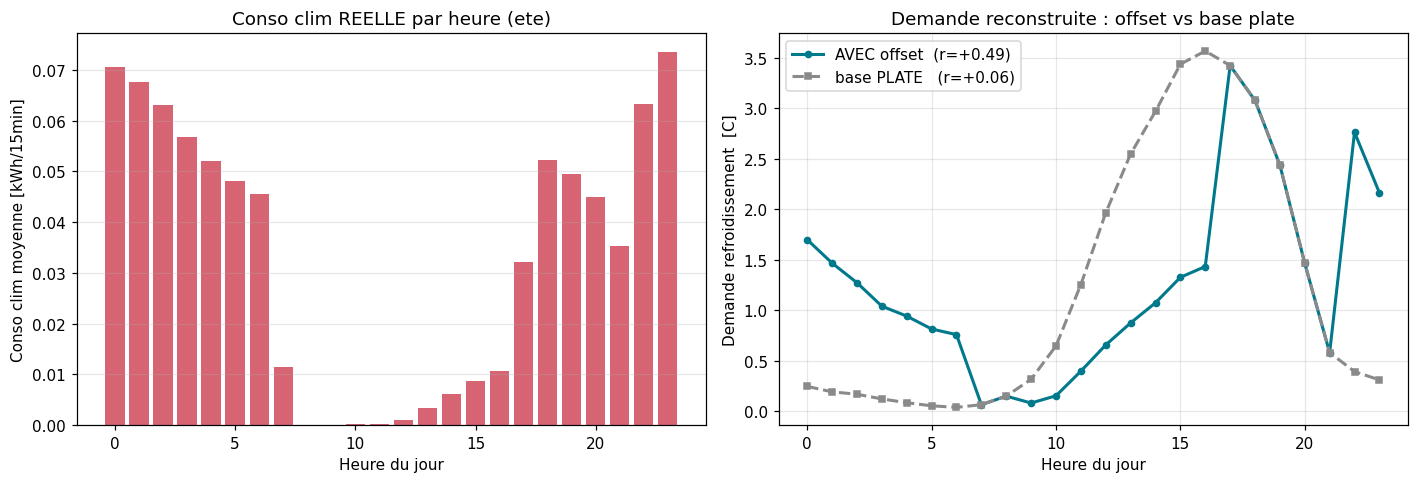

r(conso clim, demande refroidissement) sur mai-sept :
   AVEC offset (vrai masque) = +0.491
   base PLATE                = +0.056
La base plate predit un pic de clim a midi (le plus chaud) ; l offset predit le pic de nuit,
conforme a la consommation reelle. Reconstruire l offset est donc indispensable.


In [10]:
Text     = ts['out.outdoor_air_drybulb_temp..c']
dem_off  = (Text - ts['setpoint_cooling..c']).clip(lower=0)   # demande AVEC offset
dem_flat = (Text - cool_base).clip(lower=0)                    # demande base PLATE

ete3 = ts.index.month.isin([5, 6, 7, 8, 9])
c    = ts[COOL_COL]
r_off  = pearsonr(dem_off[ete3],  c[ete3])[0]
r_flat = pearsonr(dem_flat[ete3], c[ete3])[0]

# profils moyens par heure (juin-aout)
s   = ts[ts.index.month.isin([6, 7, 8])]
hh  = s.index.hour
conso_h   = s[COOL_COL].groupby(hh).mean()
demoff_h  = (s['out.outdoor_air_drybulb_temp..c'] - s['setpoint_cooling..c']).clip(lower=0).groupby(hh).mean()
demflat_h = (s['out.outdoor_air_drybulb_temp..c'] - cool_base).clip(lower=0).groupby(hh).mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(conso_h.index, conso_h.values, color='#d1495b', alpha=.85)
ax[0].set_xlabel('Heure du jour'); ax[0].set_ylabel('Conso clim moyenne [kWh/15min]')
ax[0].set_title('Conso clim REELLE par heure (ete)'); ax[0].grid(alpha=.3, axis='y')

ax[1].plot(demoff_h.index,  demoff_h.values,  color='#00798c', lw=2, marker='o', ms=4,
           label=f'AVEC offset  (r={r_off:+.2f})')
ax[1].plot(demflat_h.index, demflat_h.values, color='#8a8a8a', lw=2, ls='--', marker='s', ms=4,
           label=f'base PLATE   (r={r_flat:+.2f})')
ax[1].set_xlabel('Heure du jour'); ax[1].set_ylabel('Demande refroidissement  [C]')
ax[1].set_title('Demande reconstruite : offset vs base plate'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'r(conso clim, demande refroidissement) sur mai-sept :')
print(f'   AVEC offset (vrai masque) = {r_off:+.3f}')
print(f'   base PLATE                = {r_flat:+.3f}')
print('La base plate predit un pic de clim a midi (le plus chaud) ; l offset predit le pic de nuit,')
print('conforme a la consommation reelle. Reconstruire l offset est donc indispensable.')

## 9. Scénario d'occupation : température et clim suivent la présence

L'offset de consigne encode un **comportement d'occupant** : on refroidit quand on est présent
(nuit, soirée) et on laisse dériver quand on est absent (journée de travail). On superpose donc
le schedule d'**occupation** (stochastique, disponible dans le time series) à la consigne
reconstruite, à la température intérieure et à la consommation de clim, en profil 24 h moyen (été).

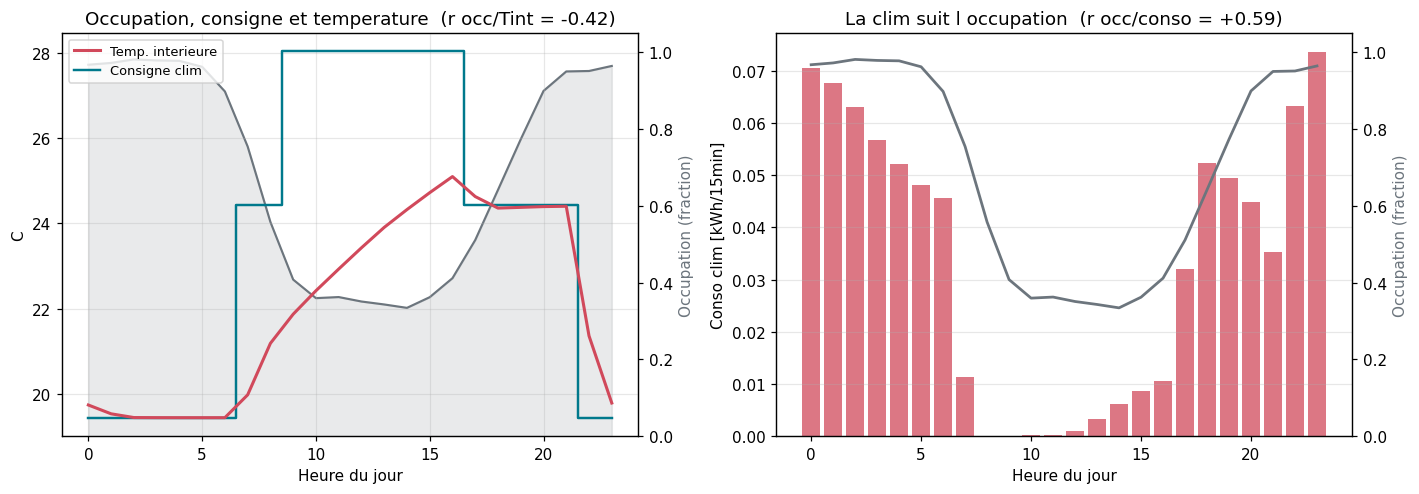

r(occupation, temp. interieure) ete = -0.416  (negatif : plus on est present, plus il fait frais)
r(occupation, conso clim)       ete = +0.590  (positif : la clim tourne quand on est la)


In [11]:
s   = ts[ts.index.month.isin([6, 7, 8])]
hh  = s.index.hour
occ   = s['out.schedules.occupants'].groupby(hh).mean()
tin   = s[T_COL].groupby(hh).mean()
sp    = s['setpoint_cooling..c'].groupby(hh).mean()
conso = s[COOL_COL].groupby(hh).mean()

r_ot = pearsonr(s['out.schedules.occupants'], s[T_COL])[0]
r_oc = pearsonr(s['out.schedules.occupants'], s[COOL_COL])[0]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# (1) occupation + consigne + temperature
a0 = ax[0]; b0 = a0.twinx()
b0.fill_between(occ.index, occ.values, color='#6c757d', alpha=.15, zorder=0)
b0.plot(occ.index, occ.values, color='#6c757d', lw=1.4, label='Occupation')
b0.set_ylabel('Occupation (fraction)', color='#6c757d'); b0.set_ylim(0, 1.05)
a0.plot(tin.index, tin.values, color='#d1495b', lw=2, label='Temp. interieure', zorder=3)
a0.step(sp.index, sp.values, where='mid', color='#00798c', lw=1.6, label='Consigne clim', zorder=2)
a0.set_xlabel('Heure du jour'); a0.set_ylabel('C'); a0.set_zorder(1); a0.patch.set_visible(False)
a0.set_title(f'Occupation, consigne et temperature  (r occ/Tint = {r_ot:+.2f})')
a0.grid(alpha=.3); a0.legend(loc='upper left', fontsize=8.5)

# (2) occupation + consommation clim
a1 = ax[1]; b1 = a1.twinx()
a1.bar(conso.index, conso.values, color='#d1495b', alpha=.75, label='Conso clim')
b1.plot(occ.index, occ.values, color='#6c757d', lw=1.8, label='Occupation')
a1.set_xlabel('Heure du jour'); a1.set_ylabel('Conso clim [kWh/15min]')
b1.set_ylabel('Occupation (fraction)', color='#6c757d'); b1.set_ylim(0, 1.05)
a1.set_title(f'La clim suit l occupation  (r occ/conso = {r_oc:+.2f})')
a1.grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

print(f'r(occupation, temp. interieure) ete = {r_ot:+.3f}  (negatif : plus on est present, plus il fait frais)')
print(f'r(occupation, conso clim)       ete = {r_oc:+.3f}  (positif : la clim tourne quand on est la)')

## Conclusion

- Les consignes non-stochastiques, **absentes** du time series, sont **reconstruites exactement**
  à partir du statique + `options_lookup.tsv` (masque signé semaine/week-end).
- La température intérieure **suit** la consigne clim quand la clim est active (viz 1 & 3).
- Les deux consignes forment une **bande morte** ; la borne active est **saisonnière** (viz 2).

**Limite** : la magnitude et le sens sont exacts ; le masque horaire est le vrai profil
`options_lookup`. Reste à vérifier sur d'autres bâtiments (setback pur, périodes décalées).